# 2-channel vs. ground truth, 4-channel vs. ground truth

Direct comparison of each channel setting **against ground truth** (not against
each other) — Dice / HD95 / ASSD, volumetric correlation, Bland-Altman, and a
final statistical verdict on which setting is closer to ground truth.

- **2-channel = Dataset 710** (fat, water)
- **4-channel = Dataset 709** (fat, water, in-phase, fat-fraction)
- All numbers below are the **held-out test split** (36 scans/model/channel
  setting) — the models never saw these masks during training, so this is the
  valid basis for an accuracy claim.
- Labels: SAT, IMAT, IMF, rectus femoris (left/right) — the 5 labels this
  analysis was scoped to (see `README.md` in this folder for why).


In [1]:
import sys
sys.path.insert(0, '.')  # this notebook lives in the same folder as common.py's parent... adjust below
import os
os.chdir('/mnt/DATAHDD/nnunet/volumetric_analysis/2026_08_reevaluation')
sys.path.insert(0, 'scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, wilcoxon
from IPython.display import display

from common import (
    MODEL_COLORS, MODEL_ORDER, CHANNEL_ORDER, PRIORITY_LABELS,
    PRIORITY_LABEL_DISPLAY, INK_SECONDARY, BASELINE,
)

pd.set_option('display.width', 140)

dice_vol = pd.read_csv('case_label_dice_volume.csv')
surf = pd.read_csv('case_label_surface_metrics.csv')
surf_ts = surf[surf.Split == 'Ts'].copy()
dice_ts = dice_vol[(dice_vol.Split == 'Ts') & (dice_vol.Label.isin(PRIORITY_LABELS))].copy()
print(f"{surf_ts.Scan.nunique()} held-out test scans per model x channel setting.")

36 held-out test scans per model x channel setting.


## 1. Dice / HD95 / ASSD — 2ch vs GT and 4ch vs GT, side by side

Mean ± SD over the 36 held-out test scans. Read as: for each label and model,
is the 2-channel or 4-channel column better (higher Dice, lower HD95/ASSD)?


In [2]:
def fmt(m, s, nd=3):
    return "" if pd.isna(m) else f"{m:.{nd}f} ± {s:.{nd}f}"

agg = (surf_ts.groupby(['Label', 'Model', 'Channels'])
       .agg(Dice_m=('Dice','mean'), Dice_s=('Dice','std'),
            HD95_m=('HD95_mm','mean'), HD95_s=('HD95_mm','std'),
            ASSD_m=('ASSD_mm','mean'), ASSD_s=('ASSD_mm','std'))
       .reset_index())

rows = []
for label in PRIORITY_LABELS:
    for model in MODEL_ORDER:
        r2 = agg[(agg.Label==label)&(agg.Model==model)&(agg.Channels=='2ch')].iloc[0]
        r4 = agg[(agg.Label==label)&(agg.Model==model)&(agg.Channels=='4ch')].iloc[0]
        rows.append({
            'Label': PRIORITY_LABEL_DISPLAY[label], 'Model': model,
            'Dice (2ch)': fmt(r2.Dice_m, r2.Dice_s), 'Dice (4ch)': fmt(r4.Dice_m, r4.Dice_s),
            'Dice winner': '2ch' if r2.Dice_m > r4.Dice_m else '4ch',
            'HD95mm (2ch)': fmt(r2.HD95_m, r2.HD95_s, 2), 'HD95mm (4ch)': fmt(r4.HD95_m, r4.HD95_s, 2),
            'HD95 winner': '2ch' if r2.HD95_m < r4.HD95_m else '4ch',
            'ASSDmm (2ch)': fmt(r2.ASSD_m, r2.ASSD_s, 2), 'ASSDmm (4ch)': fmt(r4.ASSD_m, r4.ASSD_s, 2),
            'ASSD winner': '2ch' if r2.ASSD_m < r4.ASSD_m else '4ch',
        })
summary_table = pd.DataFrame(rows)
display(summary_table.style.set_caption('Dice/HD95/ASSD: 2ch vs 4ch, held-out test')
        .set_properties(**{'text-align':'center'}))

,Label,Model,Dice (2ch),Dice (4ch),Dice winner,HD95mm (2ch),HD95mm (4ch),HD95 winner,ASSDmm (2ch),ASSDmm (4ch),ASSD winner
0,SAT,DeepLab,0.976 ± 0.011,0.978 ± 0.010,4ch,1.51 ± 1.14,1.53 ± 1.20,2ch,0.29 ± 0.18,0.29 ± 0.19,4ch
1,SAT,SwinUNETR,0.964 ± 0.015,0.968 ± 0.014,4ch,3.16 ± 3.50,2.80 ± 2.79,4ch,0.58 ± 0.43,0.52 ± 0.40,4ch
2,SAT,TopK,0.955 ± 0.017,0.956 ± 0.019,4ch,3.80 ± 3.54,3.48 ± 2.68,4ch,0.72 ± 0.46,0.65 ± 0.42,4ch
3,IMAT,DeepLab,0.889 ± 0.025,0.895 ± 0.023,4ch,2.40 ± 1.03,2.31 ± 1.08,4ch,0.44 ± 0.16,0.42 ± 0.16,4ch
4,IMAT,SwinUNETR,0.831 ± 0.031,0.841 ± 0.028,4ch,4.42 ± 1.51,4.34 ± 1.46,4ch,0.81 ± 0.27,0.78 ± 0.24,4ch
5,IMAT,TopK,0.796 ± 0.038,0.810 ± 0.038,4ch,4.97 ± 1.80,4.77 ± 1.75,4ch,0.96 ± 0.34,0.89 ± 0.31,4ch
6,IMF,DeepLab,0.838 ± 0.025,0.844 ± 0.023,4ch,2.73 ± 1.02,2.53 ± 0.99,4ch,0.51 ± 0.19,0.47 ± 0.18,4ch
7,IMF,SwinUNETR,0.766 ± 0.038,0.780 ± 0.037,4ch,4.66 ± 1.12,4.49 ± 1.12,4ch,0.84 ± 0.25,0.78 ± 0.25,4ch
8,IMF,TopK,0.724 ± 0.041,0.754 ± 0.040,4ch,5.07 ± 1.28,4.87 ± 1.29,4ch,0.95 ± 0.30,0.89 ± 0.29,4ch
9,Rectus Femoris (L),DeepLab,0.839 ± 0.120,0.842 ± 0.121,4ch,15.62 ± 18.82,21.93 ± 38.86,2ch,3.27 ± 3.38,3.84 ± 5.21,2ch


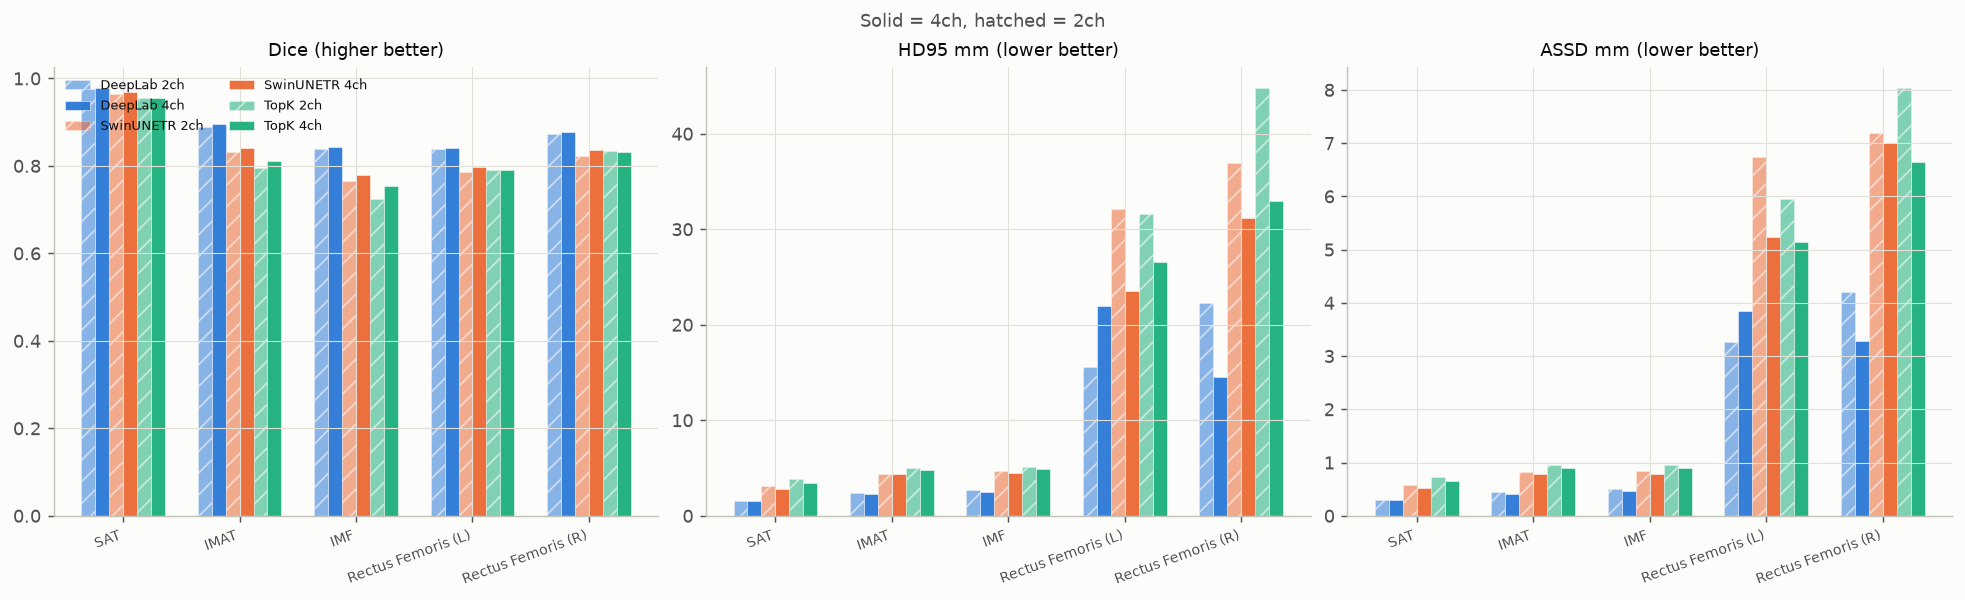

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
metrics = [('Dice_m','Dice_s','Dice (higher better)'), ('HD95_m','HD95_s','HD95 mm (lower better)'),
           ('ASSD_m','ASSD_s','ASSD mm (lower better)')]
x = np.arange(len(PRIORITY_LABELS))
width = 0.12
for ax, (mcol, scol, title) in zip(axes, metrics):
    for i, model in enumerate(MODEL_ORDER):
        for j, ch in enumerate(CHANNEL_ORDER):
            vals = [agg[(agg.Label==l)&(agg.Model==model)&(agg.Channels==ch)][mcol].values[0] for l in PRIORITY_LABELS]
            offset = (i*2+j - 2.5) * width
            hatch = None if ch == '4ch' else '//'
            ax.bar(x+offset, vals, width, color=MODEL_COLORS[model], alpha=(0.95 if ch=='4ch' else 0.55),
                   hatch=hatch, edgecolor='white', linewidth=0.3,
                   label=f'{model} {ch}' if ax is axes[0] else None)
    ax.set_xticks(x); ax.set_xticklabels([PRIORITY_LABEL_DISPLAY[l] for l in PRIORITY_LABELS], rotation=20, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=7, ncol=2, loc='upper left', frameon=False)
fig.suptitle('Solid = 4ch, hatched = 2ch', fontsize=10, color=INK_SECONDARY)
plt.show()

## 2. Volumetric correlation vs. ground truth — 2ch vs GT and 4ch vs GT

Pearson r, p-value, concordance correlation coefficient (CCC), for each label
and model, split out by channel setting.


In [4]:
def ccc(x, y):
    x, y = np.asarray(x,float), np.asarray(y,float)
    mx,my = x.mean(), y.mean(); vx,vy = x.var(ddof=1), y.var(ddof=1)
    cov = np.cov(x,y,ddof=1)[0,1]
    return (2*cov)/(vx+vy+(mx-my)**2)

corr_rows = []
for label in PRIORITY_LABELS:
    for ch in CHANNEL_ORDER:
        for model in MODEL_ORDER:
            sub = dice_ts[(dice_ts.Channels==ch)&(dice_ts.Model==model)&(dice_ts.Label==label)]
            gt, pred = sub.GT_Volume_cc.values, sub.Pred_Volume_cc.values
            r, p = pearsonr(gt, pred)
            corr_rows.append({'Label': PRIORITY_LABEL_DISPLAY[label], 'Channels': ch, 'Model': model,
                               'N': len(sub), 'Pearson_r': round(r,4), 'p_value': p, 'CCC': round(ccc(gt,pred),4)})
corr_df = pd.DataFrame(corr_rows)
pivot_r = corr_df.pivot_table(index=['Label','Model'], columns='Channels', values='Pearson_r')
pivot_r['r winner'] = np.where(pivot_r['2ch'] > pivot_r['4ch'], '2ch', '4ch')
display(pivot_r)

Channels                         2ch     4ch r winner
Label              Model                             
IMAT               DeepLab    0.9989  0.9989      4ch
                   SwinUNETR  0.9973  0.9973      4ch
                   TopK       0.9953  0.9945      2ch
IMF                DeepLab    0.9902  0.9941      4ch
                   SwinUNETR  0.9813  0.9858      4ch
                   TopK       0.9705  0.9841      4ch
Rectus Femoris (L) DeepLab    0.9144  0.8985      2ch
                   SwinUNETR  0.8616  0.8784      4ch
                   TopK       0.8846  0.8846      4ch
Rectus Femoris (R) DeepLab    0.9822  0.9746      2ch
                   SwinUNETR  0.9421  0.9244      2ch
                   TopK       0.9482  0.9465      2ch
SAT                DeepLab    0.9997  0.9997      4ch
                   SwinUNETR  0.9993  0.9995      4ch
                   TopK       0.9992  0.9989      2ch

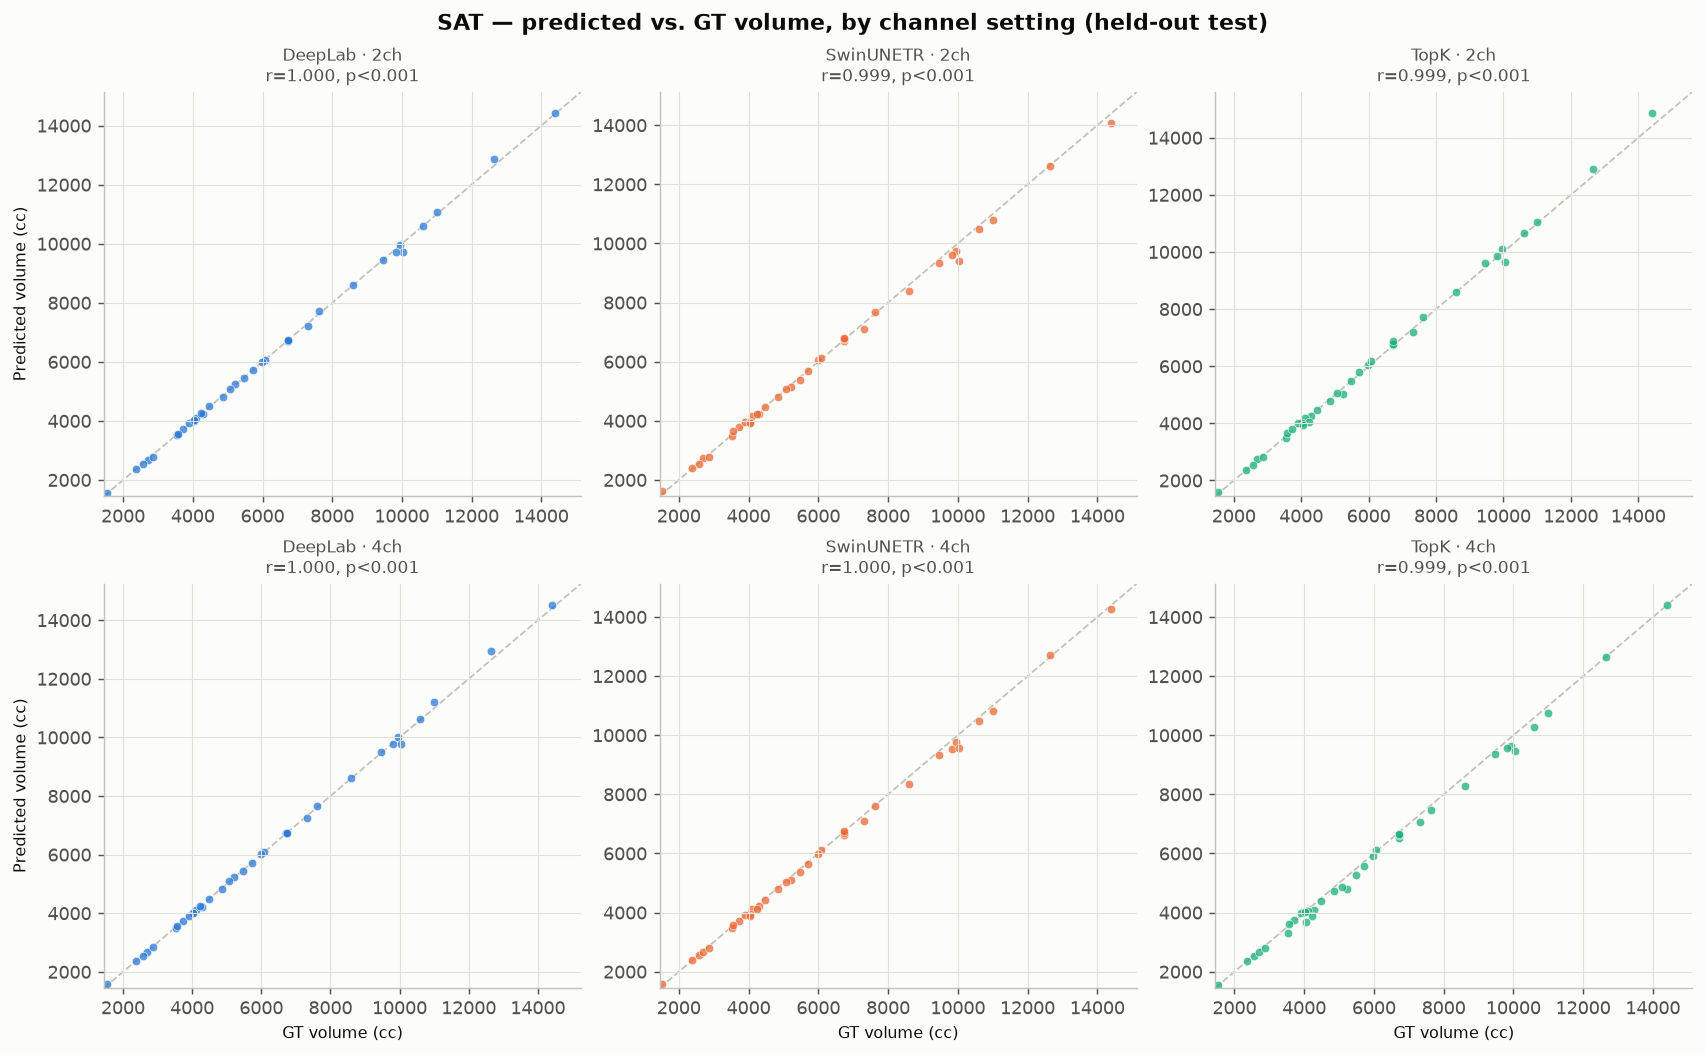

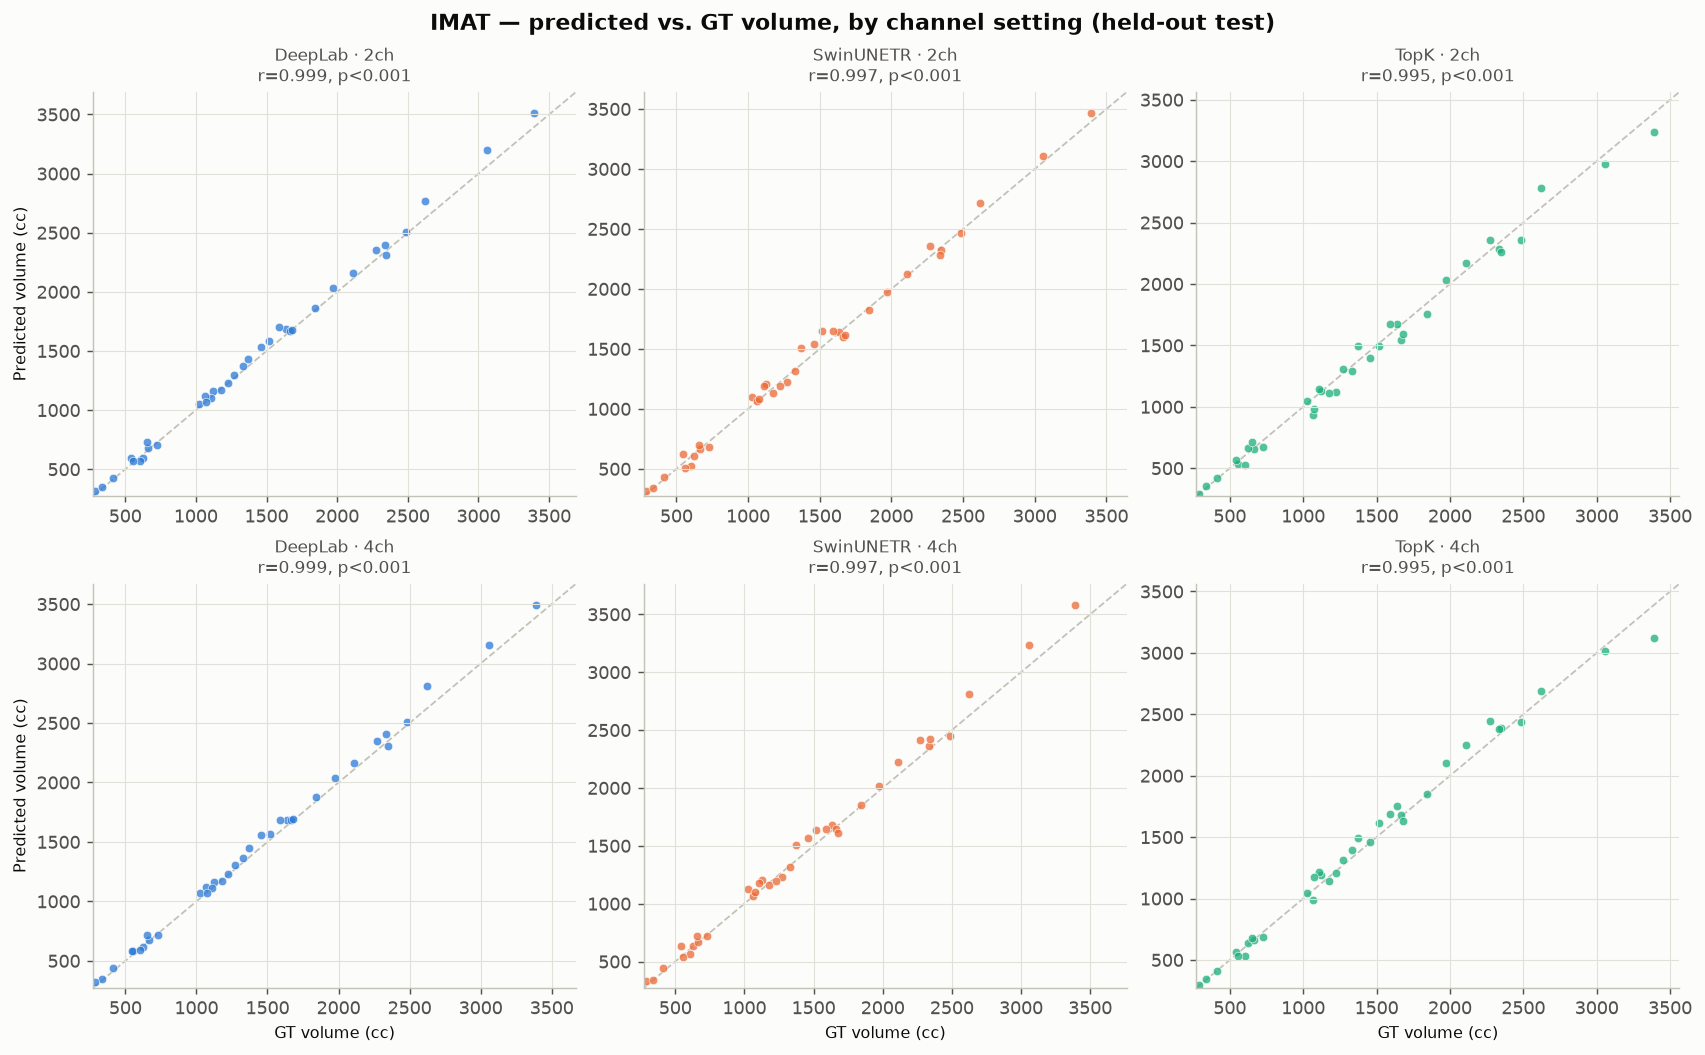

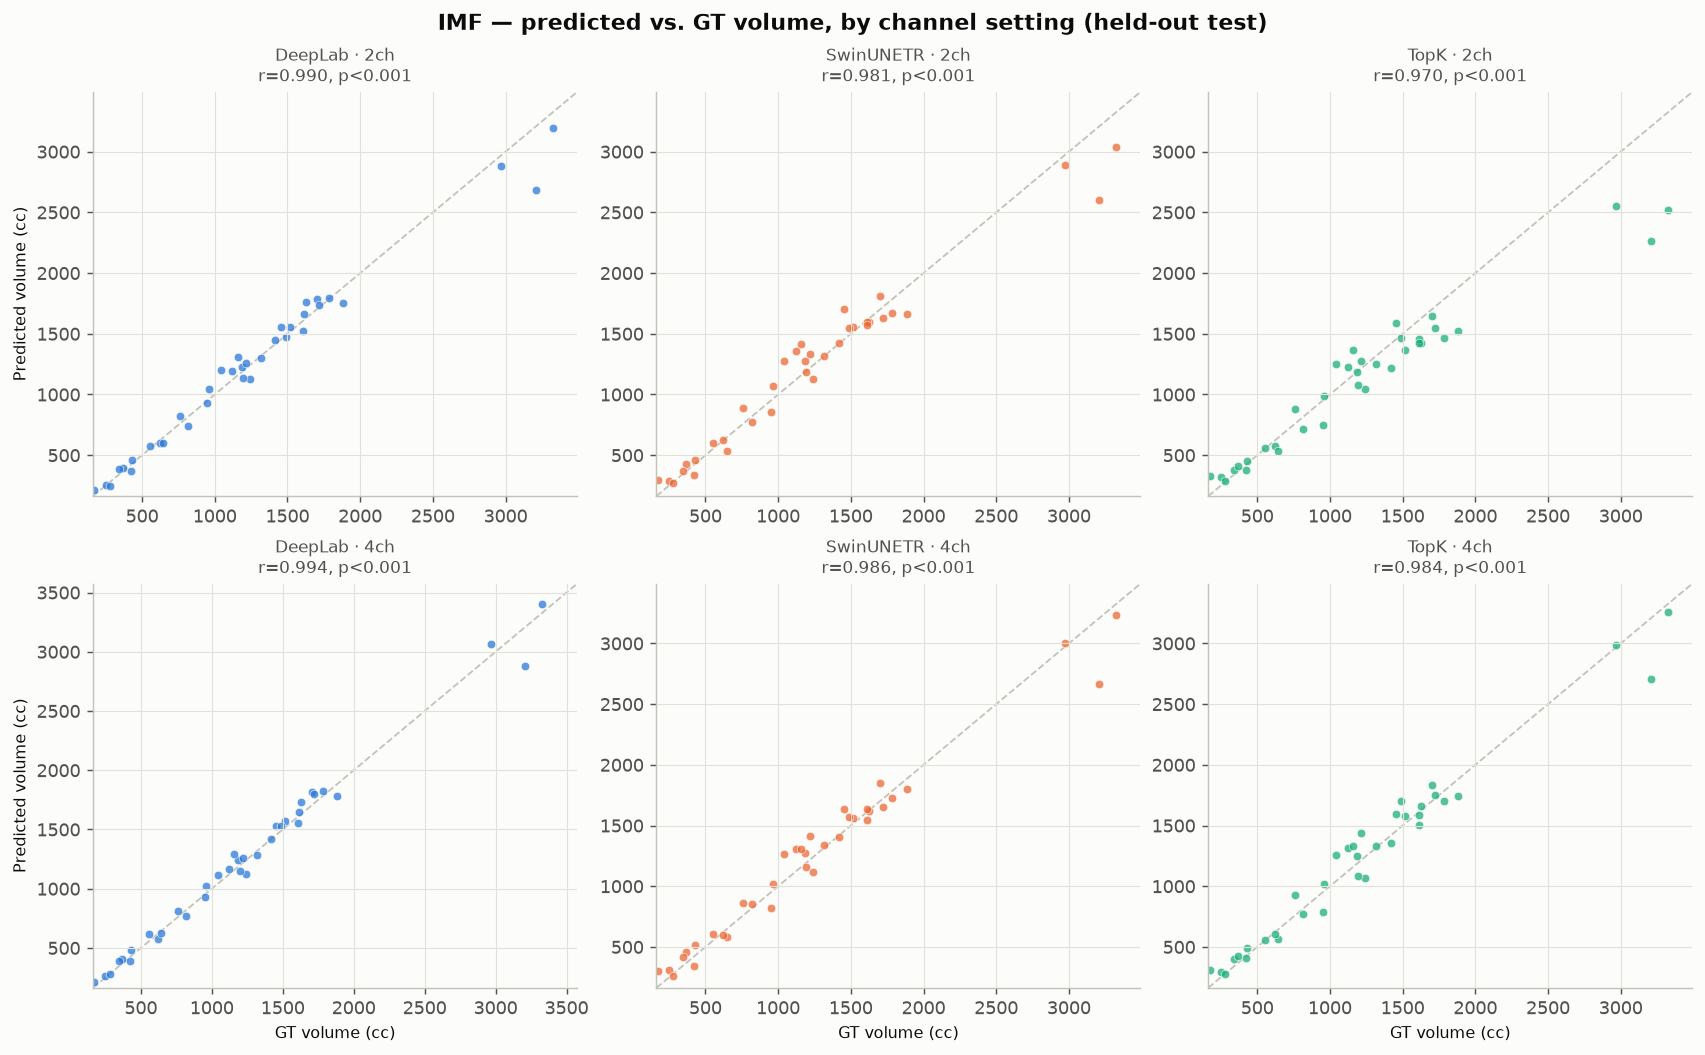

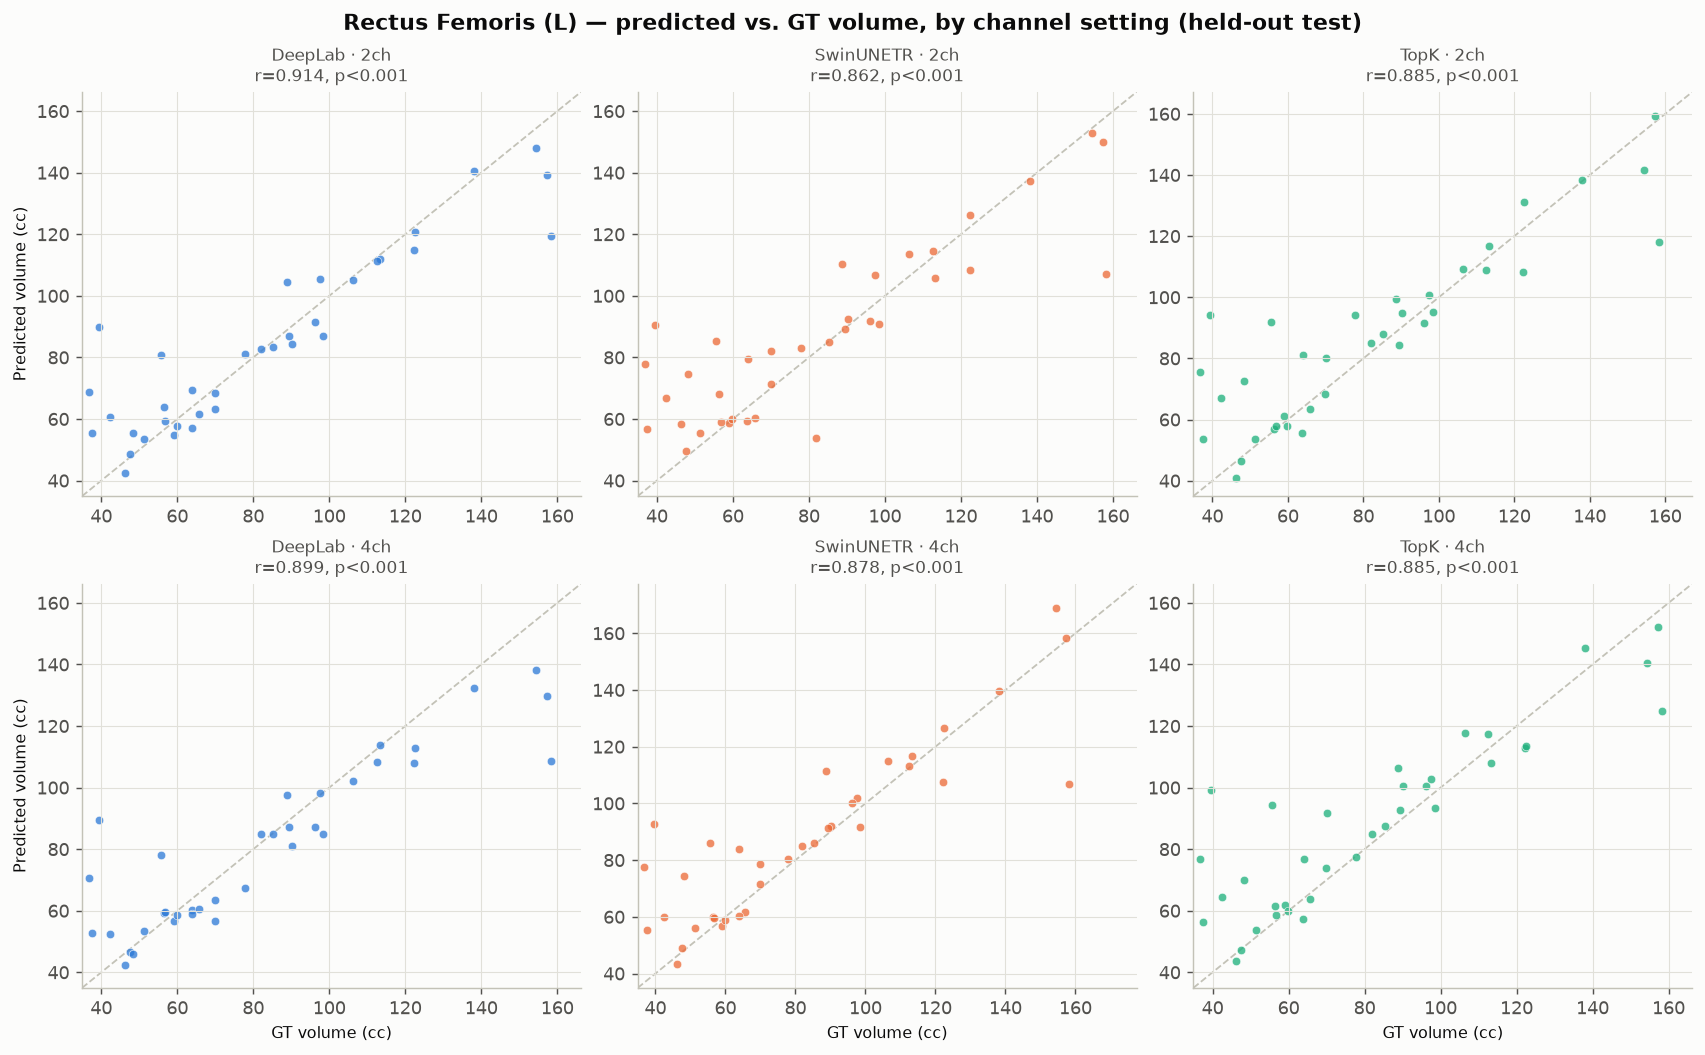

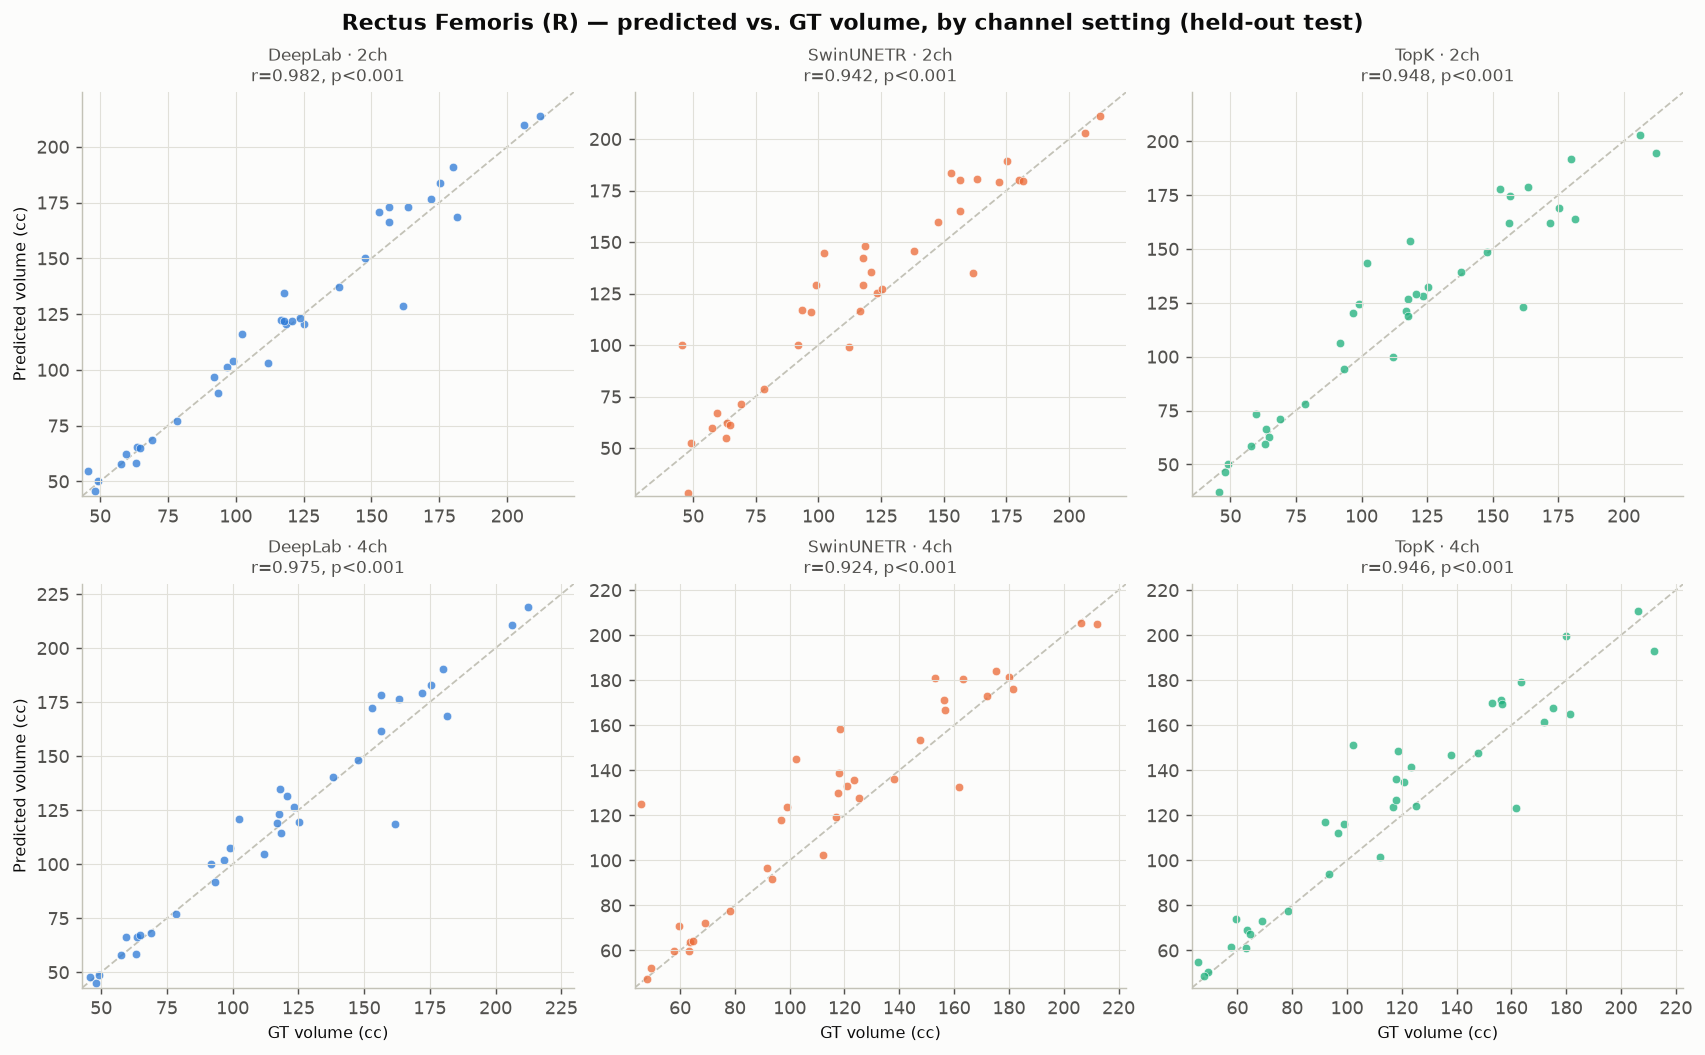

In [5]:
for label in PRIORITY_LABELS:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
    fig.suptitle(f'{PRIORITY_LABEL_DISPLAY[label]} — predicted vs. GT volume, by channel setting (held-out test)',
                 fontsize=12, fontweight='bold')
    for row, ch in enumerate(CHANNEL_ORDER):
        for col, model in enumerate(MODEL_ORDER):
            ax = axes[row, col]
            sub = dice_ts[(dice_ts.Channels==ch)&(dice_ts.Model==model)&(dice_ts.Label==label)]
            gt, pred = sub.GT_Volume_cc.values, sub.Pred_Volume_cc.values
            r, p = pearsonr(gt, pred)
            ax.scatter(gt, pred, s=22, color=MODEL_COLORS[model], alpha=0.75, edgecolor='white', linewidth=0.4)
            lo, hi = min(gt.min(),pred.min())*0.95, max(gt.max(),pred.max())*1.05
            ax.plot([lo,hi],[lo,hi], color=BASELINE, linestyle='--', linewidth=1, zorder=0)
            ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
            p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
            ax.set_title(f'{model} · {ch}\nr={r:.3f}, {p_str}', fontsize=9.5, color=INK_SECONDARY)
            if row==1: ax.set_xlabel('GT volume (cc)', fontsize=9)
            if col==0: ax.set_ylabel('Predicted volume (cc)', fontsize=9)
    plt.show()

## 3. Bland-Altman vs. ground truth — 2ch vs GT and 4ch vs GT

Bias and 95% limits of agreement, predicted minus ground-truth volume.


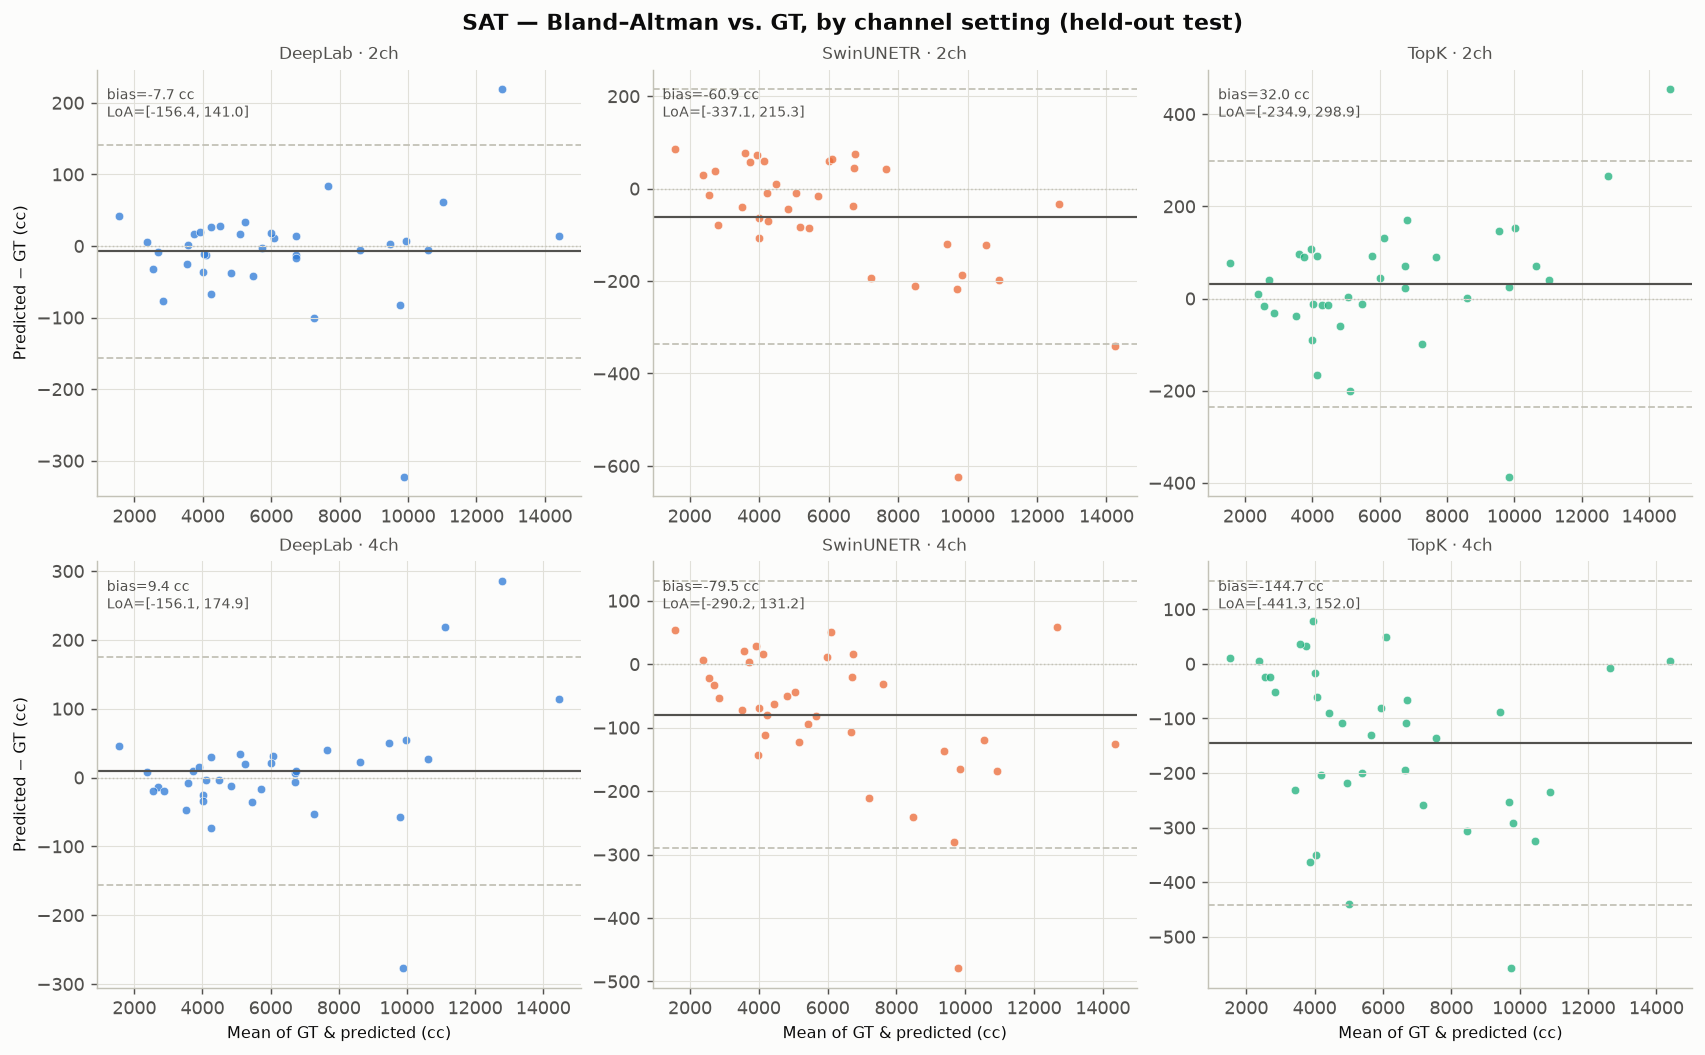

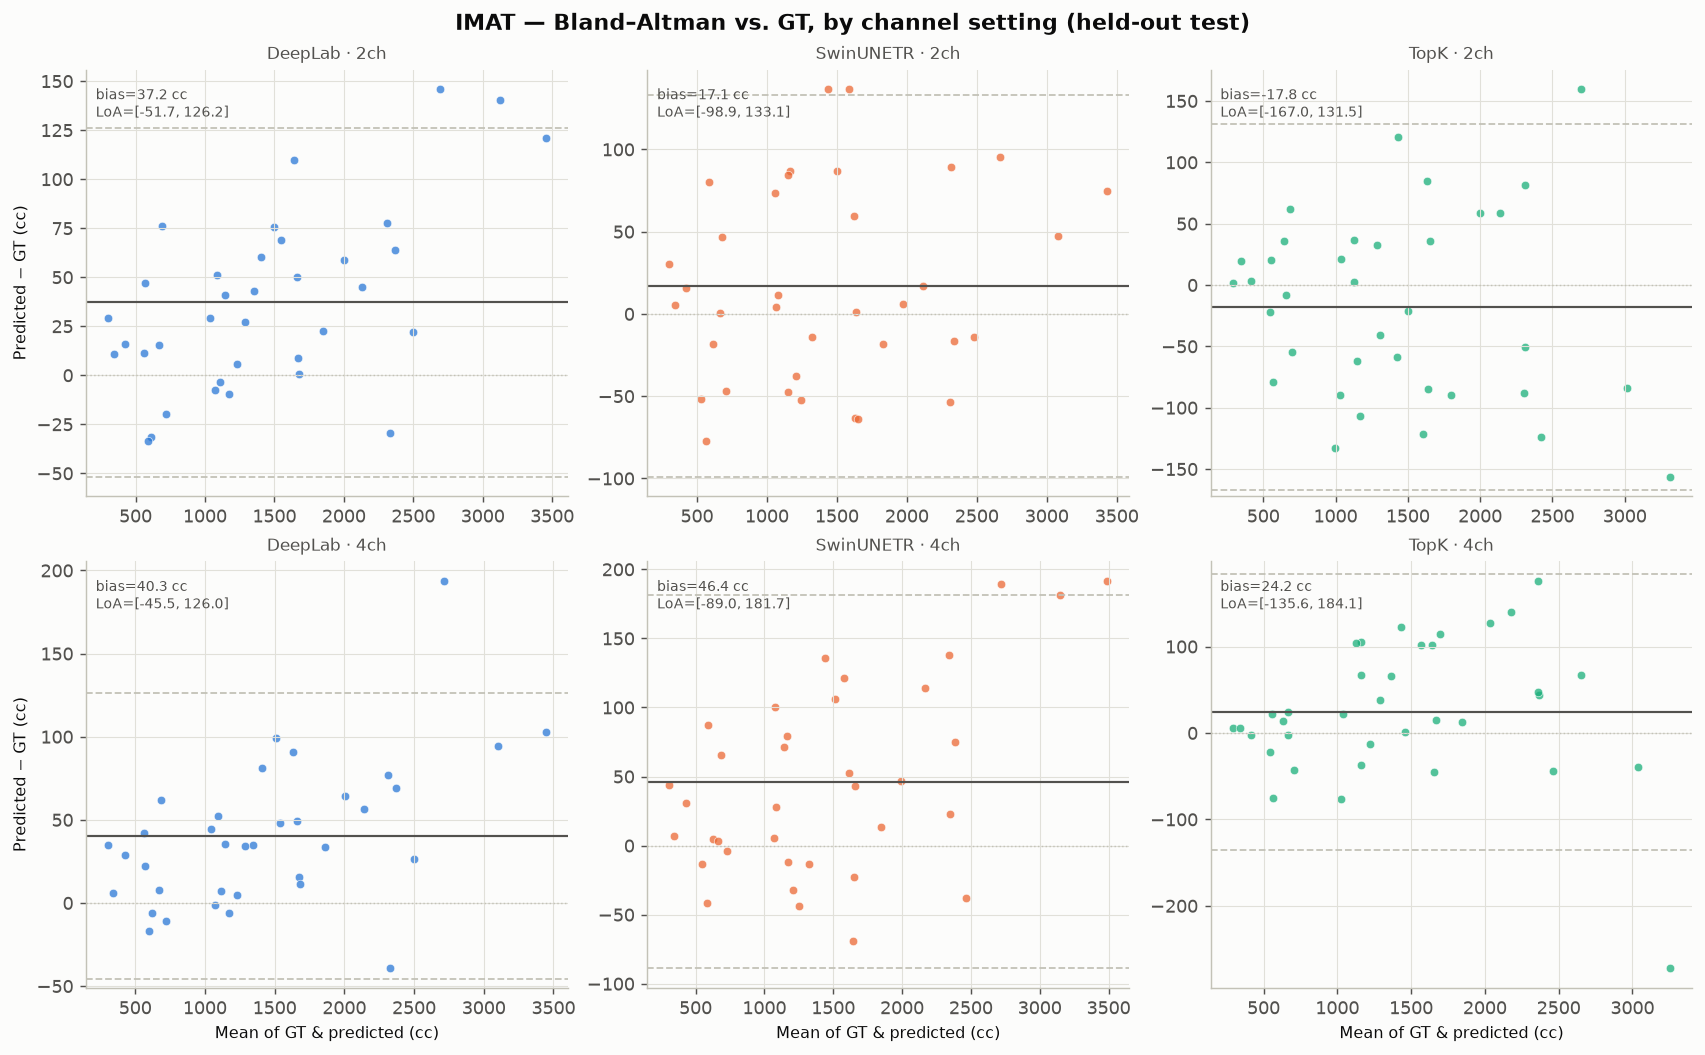

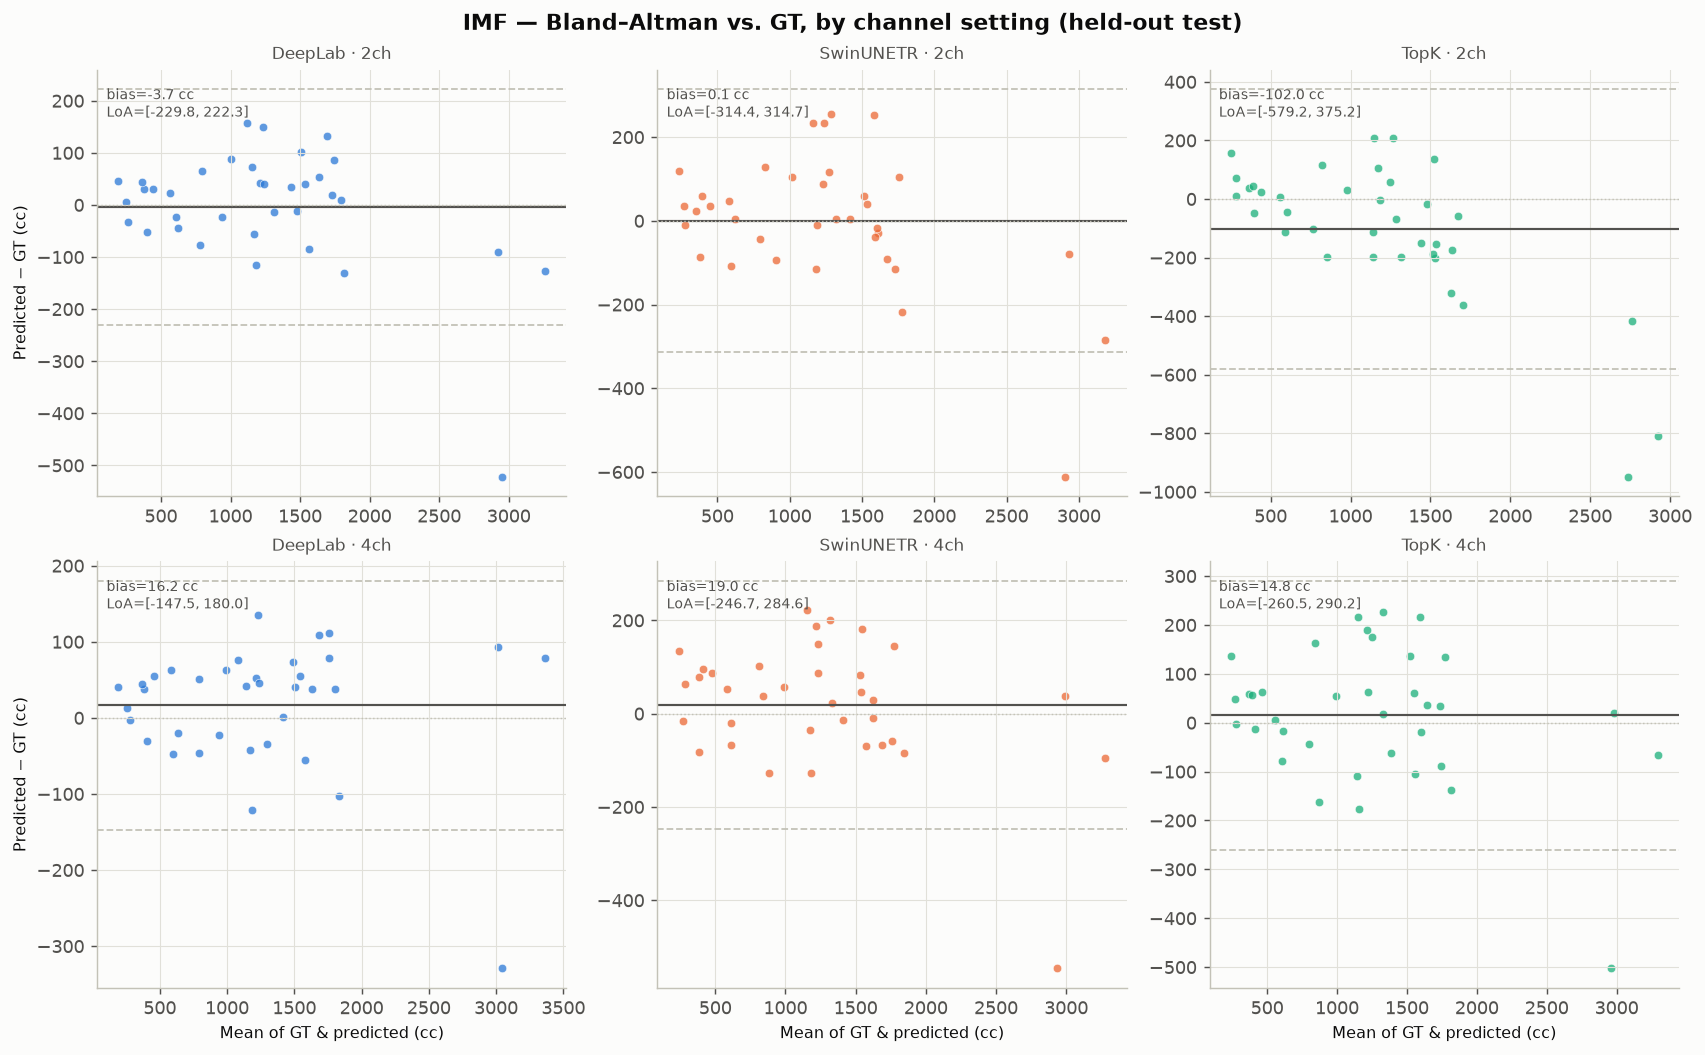

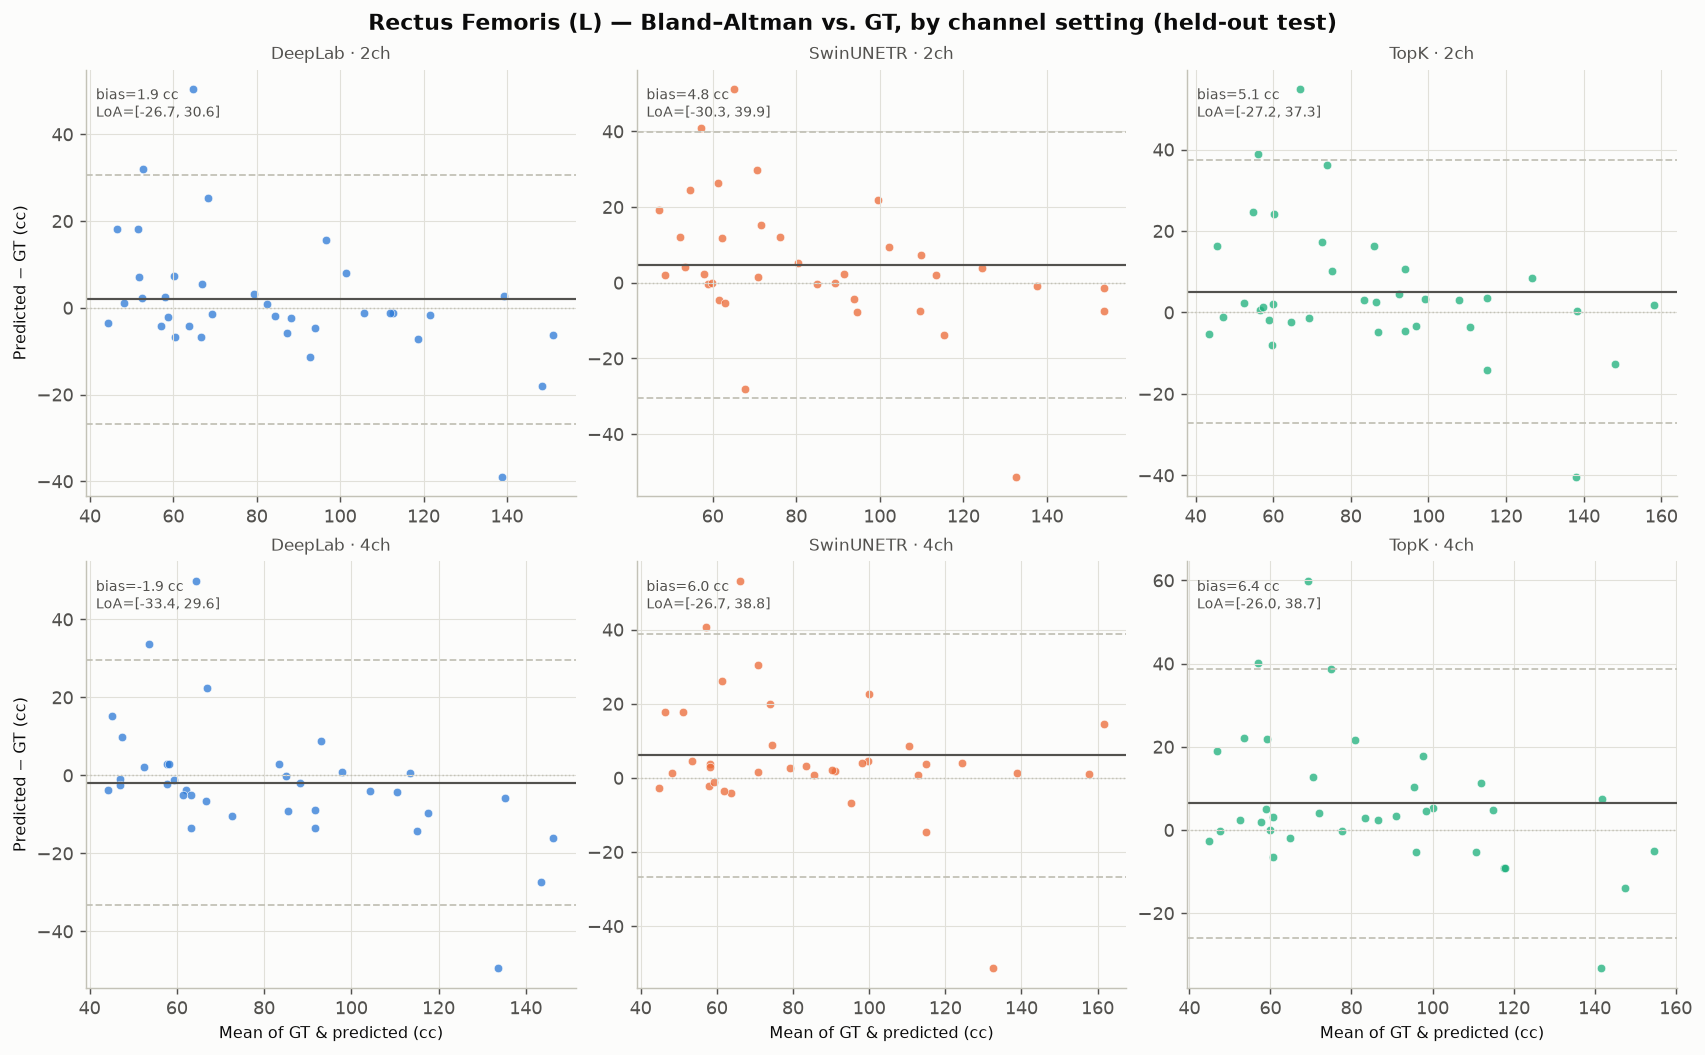

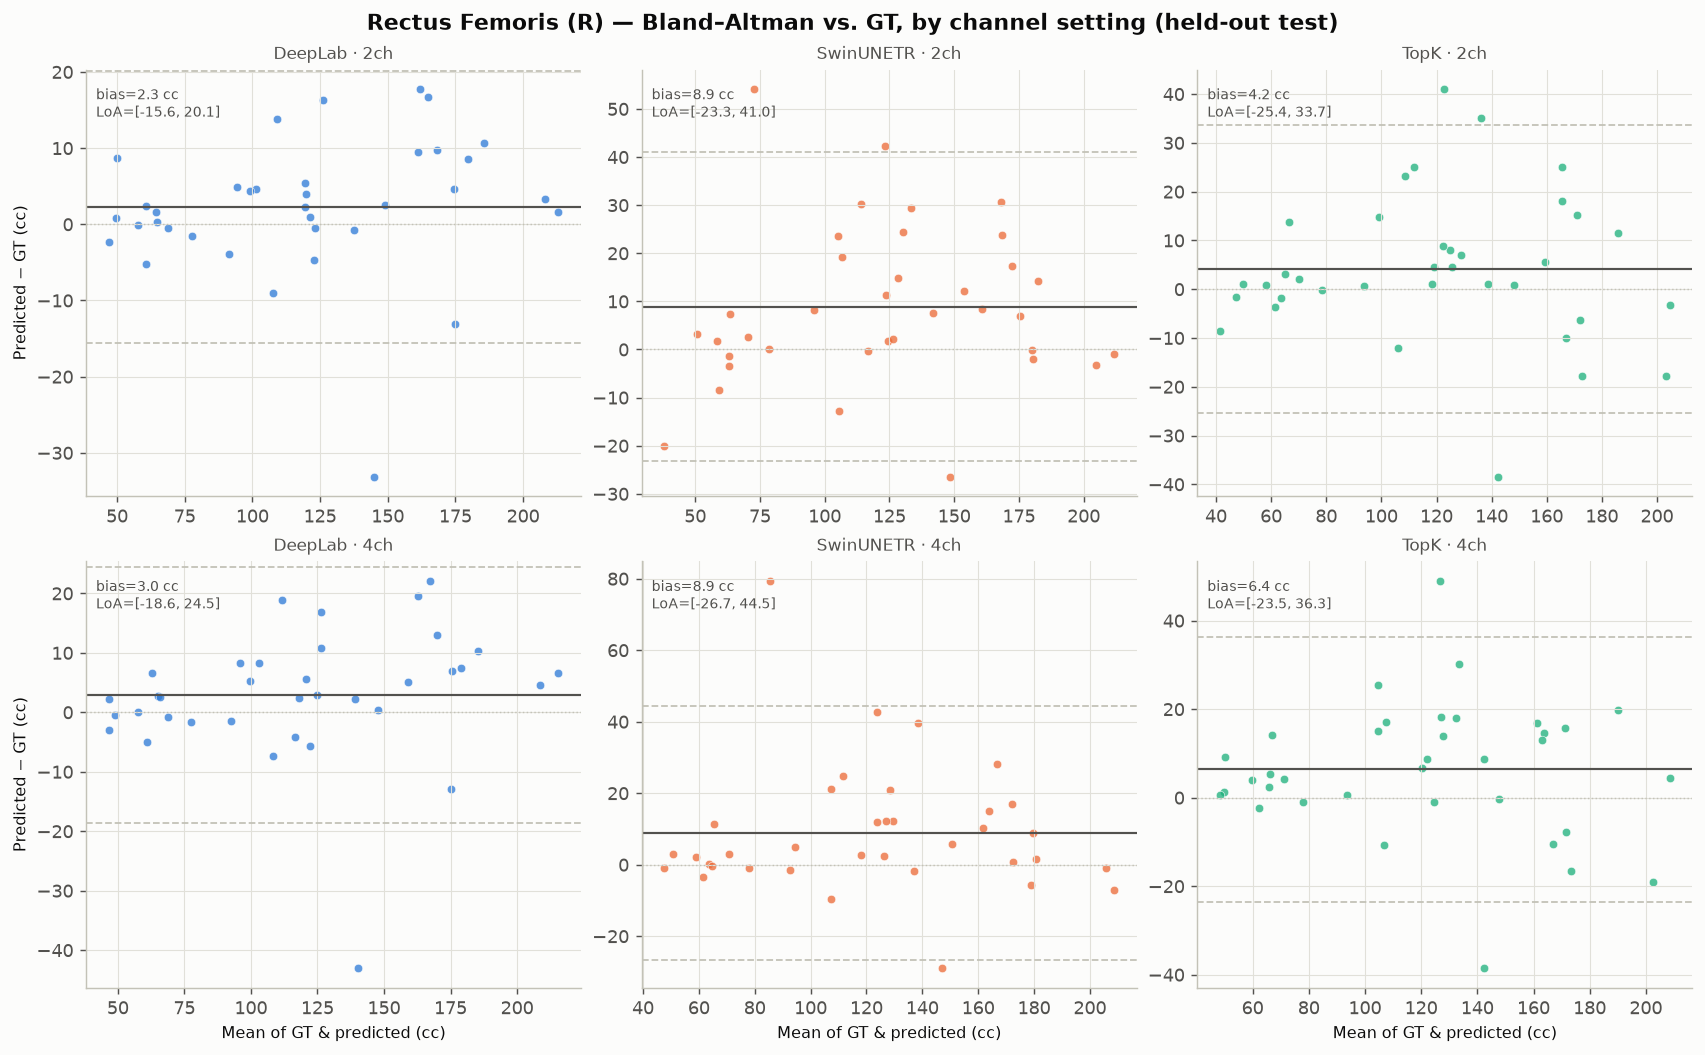

In [6]:
for label in PRIORITY_LABELS:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
    fig.suptitle(f'{PRIORITY_LABEL_DISPLAY[label]} — Bland–Altman vs. GT, by channel setting (held-out test)',
                 fontsize=12, fontweight='bold')
    for row, ch in enumerate(CHANNEL_ORDER):
        for col, model in enumerate(MODEL_ORDER):
            ax = axes[row, col]
            sub = dice_ts[(dice_ts.Channels==ch)&(dice_ts.Model==model)&(dice_ts.Label==label)]
            gt, pred = sub.GT_Volume_cc.values, sub.Pred_Volume_cc.values
            mean, diff = (gt+pred)/2, pred-gt
            ax.scatter(mean, diff, s=22, color=MODEL_COLORS[model], alpha=0.75, edgecolor='white', linewidth=0.4)
            bias, sd = diff.mean(), diff.std(ddof=1)
            ax.axhline(bias, color=INK_SECONDARY, linewidth=1.2)
            ax.axhline(bias+1.96*sd, color=BASELINE, linestyle='--', linewidth=1)
            ax.axhline(bias-1.96*sd, color=BASELINE, linestyle='--', linewidth=1)
            ax.axhline(0, color=BASELINE, linestyle=':', linewidth=0.8)
            ax.text(0.02,0.96, f'bias={bias:.1f} cc\nLoA=[{bias-1.96*sd:.1f}, {bias+1.96*sd:.1f}]',
                    transform=ax.transAxes, fontsize=8, va='top', color=INK_SECONDARY)
            ax.set_title(f'{model} · {ch}', fontsize=9.5, color=INK_SECONDARY)
            if row==1: ax.set_xlabel('Mean of GT & predicted (cc)', fontsize=9)
            if col==0: ax.set_ylabel('Predicted − GT (cc)', fontsize=9)
    plt.show()

## 4. Verdict: which channel setting is closer to ground truth?

Paired Wilcoxon signed-rank test on **absolute volume error** (|predicted − GT|),
2ch vs 4ch, matched scan-by-scan (same subject, same model). p<0.05 means the
gap is unlikely to be chance; anything else means the two channel settings are
statistically indistinguishable for that label/model.


In [7]:
ts = dice_ts.copy()
ts['Abs_Error_cc'] = (ts.Pred_Volume_cc - ts.GT_Volume_cc).abs()
err_wide = ts.pivot_table(index=['Model','Scan','Label'], columns='Channels', values='Abs_Error_cc').dropna().reset_index()

verdict_rows = []
for label in PRIORITY_LABELS:
    for model in MODEL_ORDER:
        sub = err_wide[(err_wide.Model==model)&(err_wide.Label==label)]
        e2, e4 = sub['2ch'].values, sub['4ch'].values
        diff = e2 - e4
        try:
            _, p = wilcoxon(diff)
        except ValueError:
            p = np.nan
        winner = '2ch' if e2.mean() < e4.mean() else '4ch'
        sig = 'significant' if (not np.isnan(p) and p < 0.05) else 'not significant'
        verdict_rows.append({'Label': PRIORITY_LABEL_DISPLAY[label], 'Model': model,
                              'Mean |err| 2ch (cc)': round(e2.mean(),1), 'Mean |err| 4ch (cc)': round(e4.mean(),1),
                              'Closer to GT': winner, 'Wilcoxon p': round(p,4) if not np.isnan(p) else np.nan,
                              'Result': sig})
verdict_df = pd.DataFrame(verdict_rows)
display(verdict_df.style.apply(
    lambda r: ['background-color:#cde2fb' if r['Result']=='significant' else '' for _ in r], axis=1))

n_sig = (verdict_df.Result == 'significant').sum()
n_2ch_wins = (verdict_df['Closer to GT']=='2ch').sum()
n_4ch_wins = (verdict_df['Closer to GT']=='4ch').sum()
n_2ch_sig = ((verdict_df['Closer to GT']=='2ch') & (verdict_df.Result=='significant')).sum()
n_4ch_sig = ((verdict_df['Closer to GT']=='4ch') & (verdict_df.Result=='significant')).sum()
print(f"Across {len(verdict_df)} label×model comparisons:")
print(f"  2ch numerically closer to GT in {n_2ch_wins} ({n_2ch_sig} statistically significant)")
print(f"  4ch numerically closer to GT in {n_4ch_wins} ({n_4ch_sig} statistically significant)")
print(f"  Only {n_sig}/{len(verdict_df)} comparisons reach p<0.05 -- most differences are NOT statistically significant.")

,Label,Model,Mean |err| 2ch (cc),Mean |err| 4ch (cc),Closer to GT,Wilcoxon p,Result
0,SAT,DeepLab,42.300000,48.600000,2ch,0.834100,not significant
1,SAT,SwinUNETR,100.500000,94.300000,4ch,0.895100,not significant
2,SAT,TopK,95.300000,156.600000,2ch,0.016800,significant
3,IMAT,DeepLab,44.700000,44.700000,2ch,0.895100,not significant
4,IMAT,SwinUNETR,49.000000,62.500000,2ch,0.186600,not significant
5,IMAT,TopK,64.200000,61.600000,4ch,0.669400,not significant
6,IMF,DeepLab,74.300000,63.700000,4ch,0.161500,not significant
7,IMF,SwinUNETR,108.200000,97.700000,4ch,0.602800,not significant
8,IMF,TopK,169.600000,102.800000,4ch,0.028300,significant
9,Rectus Femoris (L),DeepLab,9.200000,10.300000,2ch,0.220400,not significant


Across 15 label×model comparisons:
  2ch numerically closer to GT in 8 (2 statistically significant)
  4ch numerically closer to GT in 7 (1 statistically significant)
  Only 3/15 comparisons reach p<0.05 -- most differences are NOT statistically significant.


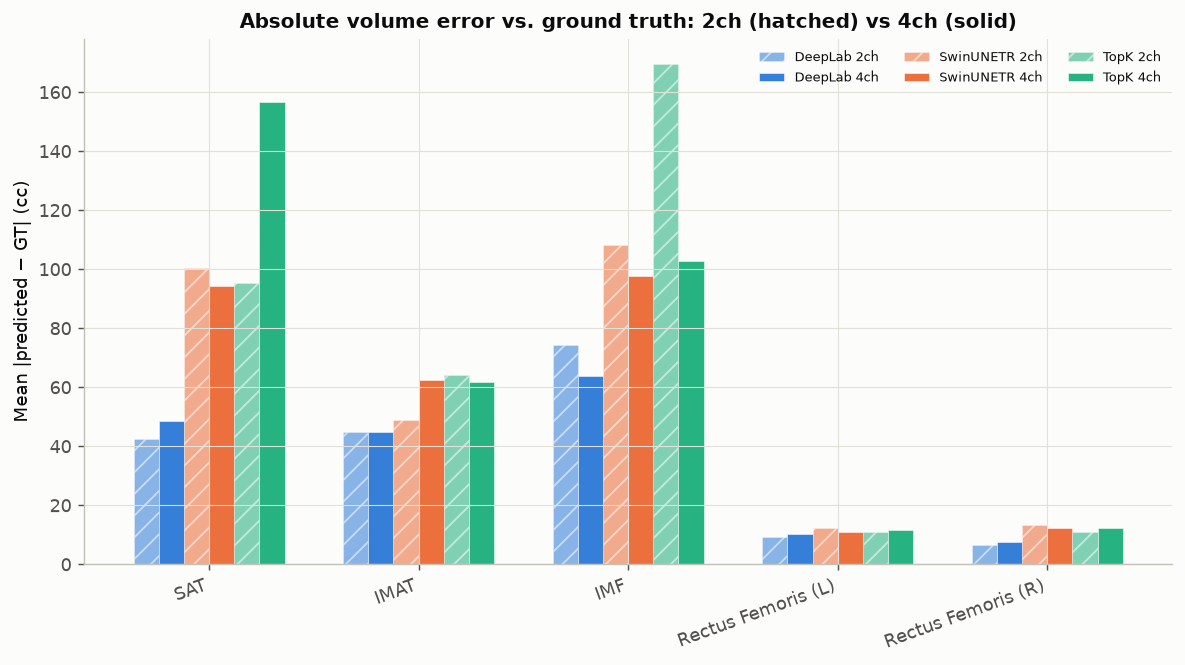

In [8]:
fig, ax = plt.subplots(figsize=(9,5), constrained_layout=True)
labels_disp = [PRIORITY_LABEL_DISPLAY[l] for l in PRIORITY_LABELS]
x = np.arange(len(PRIORITY_LABELS)); width=0.12
for i, model in enumerate(MODEL_ORDER):
    e2 = [verdict_df[(verdict_df.Label==l)&(verdict_df.Model==model)]['Mean |err| 2ch (cc)'].values[0] for l in labels_disp]
    e4 = [verdict_df[(verdict_df.Label==l)&(verdict_df.Model==model)]['Mean |err| 4ch (cc)'].values[0] for l in labels_disp]
    off = (i*2 - 2.5) * width
    ax.bar(x+off, e2, width, color=MODEL_COLORS[model], alpha=0.55, hatch='//', edgecolor='white', linewidth=0.3,
           label=f'{model} 2ch')
    ax.bar(x+off+width, e4, width, color=MODEL_COLORS[model], alpha=0.95, edgecolor='white', linewidth=0.3,
           label=f'{model} 4ch')
ax.set_xticks(x); ax.set_xticklabels(labels_disp, rotation=20, ha='right')
ax.set_ylabel('Mean |predicted − GT| (cc)')
ax.set_title('Absolute volume error vs. ground truth: 2ch (hatched) vs 4ch (solid)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, ncol=3, frameon=False)
plt.show()

## 5. Overall Dice score by model

Macro-average Dice across the 5 priority labels (SAT, IMAT, IMF, rectus
femoris L/R), held-out test split — first split by channel setting, then
pooled across both channel settings for a single per-model number.


In [9]:
overall_by_channel = (surf_ts.groupby(['Model', 'Channels'])['Dice']
                       .agg(Dice_mean='mean', Dice_std='std', N='count')
                       .reset_index())
overall_by_channel['Dice'] = overall_by_channel.apply(lambda r: fmt(r.Dice_mean, r.Dice_std), axis=1)
overall_by_channel['Model'] = pd.Categorical(overall_by_channel.Model, MODEL_ORDER, ordered=True)
display(overall_by_channel[['Model', 'Channels', 'N', 'Dice']]
        .sort_values(['Model', 'Channels'])
        .style.set_caption('Overall Dice (macro-avg over SAT/IMAT/IMF/RF-L/RF-R), held-out test')
        .hide(axis='index'))

overall_by_model = (surf_ts.groupby('Model')['Dice']
                     .agg(Dice_mean='mean', Dice_std='std', N='count')
                     .reset_index())
overall_by_model['Dice'] = overall_by_model.apply(lambda r: fmt(r.Dice_mean, r.Dice_std), axis=1)
overall_by_model = overall_by_model.set_index('Model').loc[MODEL_ORDER].reset_index()
display(overall_by_model[['Model', 'N', 'Dice']]
        .style.set_caption('Overall Dice per model (2ch+4ch pooled), held-out test')
        .hide(axis='index'))

Model,Channels,N,Dice
DeepLab,2ch,180,0.883 ± 0.084
DeepLab,4ch,180,0.887 ± 0.082
SwinUNETR,2ch,180,0.834 ± 0.106
SwinUNETR,4ch,180,0.845 ± 0.105
TopK,2ch,180,0.820 ± 0.111
TopK,4ch,180,0.828 ± 0.106


Model,N,Dice
DeepLab,360,0.885 ± 0.083
SwinUNETR,360,0.839 ± 0.106
TopK,360,0.824 ± 0.108


## 6. Bottom line

- **No channel setting is uniformly better.** Across the 15 label×model
  comparisons on held-out test data, which setting is numerically closer to
  ground truth flips by label and by model, and the large majority of those
  gaps are **not statistically significant** (paired Wilcoxon p>0.05) — see
  the counts printed in section 4.
- Where a gap *is* significant, it is usually small relative to typical organ
  volume (a few percent), not a change that would alter clinical or research
  conclusions.
- **Practical takeaway**: the 2 extra channels in Dataset 709 (in-phase,
  fat-fraction) are not buying measurable extra accuracy against ground truth
  on this cohort. If acquisition time/cost matters, 2-channel (fat, water)
  segmentation is not meaningfully worse than 4-channel for SAT, IMAT, IMF, or
  rectus femoris volumetry with any of the 3 models tested.
- The model choice matters far more than the channel count: DeepLab beats
  SwinUNETR and TopK by a wide margin on every label in both channel settings,
  and by the macro-averaged overall Dice in section 5 (see the main
  `README.md` for full Dice/HD95/ASSD numbers).
